In [4]:
import pandas as pd
import os,torch,collections
import numpy as np
#go through formual mask ious in overlap/ and record how ovvverlap changes across iters for each pruning
root="/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run0.25"


#if root=wanda
c1=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
c2=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
c3=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']


active_neuron_per_cluster=[c1,c2,c3]
def convert(x):
    if isinstance(x, str) and x.startswith('tensor'):
        # Remove 'torch.tensor(' and ')' to get the list
        tensor_str = x[7:-1]
        return torch.tensor(eval(tensor_str)).item()
    elif isinstance(x, str):
        # If the entry is a number (int or float), convert it to a tensor
        return float(x)
    else:
        # If the entry is already a tensor, return it as is
        return x
from sortedcontainers import SortedDict
pruned_percents=[0.0, 0.25, 0.44, 0.58, 0.68, 0.76]

def get_aligments(root, active_neuron_per_cluster):
    stored_alignments=collections.defaultdict(lambda : collections.defaultdict())
    for cluster in os.listdir(os.path.join(root)):
        if '.ipynb_checkpoints' in cluster: continue
        for alignment in os.listdir(os.path.join(root, cluster)):
            #if '_between' in alignment: continue
            if alignment == '.ipynb_checkpoints': continue
            file = os.path.join(root, cluster, alignment)
            
            overlap_file = pd.read_csv(file)
            overlap_file['iou'] = overlap_file['iou'].apply(lambda x: convert(x))
            overlap_file['neuron']= overlap_file['neuron'].apply(lambda x: int(x))
            active_neurons = {}
            for neuron, iou in zip(overlap_file[overlap_file['iou'] >0]['neuron'], overlap_file[overlap_file['iou'] >0]['iou']):
                active_neurons[neuron] = np.round(iou,3)
            for neuron in active_neuron_per_cluster[int(cluster[7:])-1]:
                if neuron not in active_neurons:
                    active_neurons[neuron] = 0
     
            #pruning_iter = int(alignment.split("_")[4])  #this is for alignment w random
         
            try:
                pruning_iter = int(alignment[:alignment.index('I')])  #this for alignment with orig
            except:
                continue
            
            stored_alignments[pruned_percents[pruning_iter]*100][cluster] = SortedDict(active_neurons)
    return stored_alignments
    

        
    

#get all neurons in 0% pruning
#go to all other files:
#stored_alignments=get_aligments(root, active_neuron_per_cluster)

In [5]:
import matplotlib.pyplot as plt
def plot(root, alignment_changes):
    """
    Create three plots, each highlighting a different cluster's min/max range
    
    Parameters:
    - method: str, title prefix for the plots
    - alignment_changes: tuple of (c1, c2, c3) dictionaries with alignment values
    - mins: tuple of (min1, min2, min3) dictionaries with minimum values
    - maxs: tuple of (max1, max2, max3) dictionaries with maximum values
    """
    alignment_change_c1, alignment_change_c2, alignment_change_c3 = alignment_changes
   
    
    # Define cluster colors for consistency
    colors = {'c1': 'blue', 'c2': 'orange', 'c3': 'green'}
    markers = {'c1': 'o', 'c2': 's', 'c3': '^'}
    
    def create_single_plot():
        plt.figure(figsize=(10, 6))
        
        # Plot all three lines
        plt.plot(list(alignment_change_c1.keys()), list(alignment_change_c1.values()), 
                label='Cluster 1', marker=markers['c1'], color=colors['c1'])
        plt.plot(list(alignment_change_c2.keys()), list(alignment_change_c2.values()), 
                label='Cluster 2', marker=markers['c2'], color=colors['c2'])
        plt.plot(list(alignment_change_c3.keys()), list(alignment_change_c3.values()), 
                label='Cluster 3', marker=markers['c3'], color=colors['c3'])
        
        # Customize the plot
        plt.xlabel('Pruned %')
        plt.ylabel('Overlap')
        plt.title(f'{root}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.margins(x=0.05)
        plt.tight_layout()
        plt.show()
    
    # Create three plots, each highlighting a different cluster
    create_single_plot()

In [6]:
def get_avg_alignment(stored_alignments):
    alignment_change_c1={}
    min_change_c1={}
    max_change_c1 ={}
    for per in sorted(stored_alignments.keys()):
        #print(per, stored_alignments[per].keys())
        if f'Cluster1' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster1'].values())
            ious = [iou for iou in ious if iou > 0]
        
            avg = sum(ious)/len(ious)
            min_ = min([x for x in ious if x != 0])
            max_ = max(ious)
        else:
            avg=0
        alignment_change_c1[per] = avg
        min_change_c1[per] = min_
        max_change_c1[per] = max_

    alignment_change_c2={}
    min_change_c2={}
    max_change_c2 ={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster2' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster2'].values())
            ious = [iou for iou in ious if iou > 0]
            avg = sum(ious)/len(ious)
            min_ = min([x for x in ious if x != 0])
            max_ = max(ious)
        else:
            avg=0
        alignment_change_c2[per] = avg
        min_change_c2[per] = min_
        max_change_c2[per] = max_

    alignment_change_c3={}
    min_change_c3={}
    max_change_c3={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster3' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster3'].values())
            ious = [iou for iou in ious if iou > 0]
            
            avg = sum(ious)/len(ious)
            min_ = min(ious)
            max_ = max(ious)
            alignment_change_c3[per] = avg
            min_change_c3[per] = min_
            max_change_c3[per] = max_
    align_changes = [alignment_change_c1, alignment_change_c2, alignment_change_c3]
    min_changes = [min_change_c1, min_change_c2, min_change_c3]
    max_changes = [max_change_c1, max_change_c2, max_change_c3]
    return align_changes, min_changes, max_changes

In [63]:
root="/workspace/CCE_NLI/BERT/overlap/lottery_ticket/overlap_w_orig/Run3"
stored_alignments=get_aligments(root, active_neuron_per_cluster)
alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)

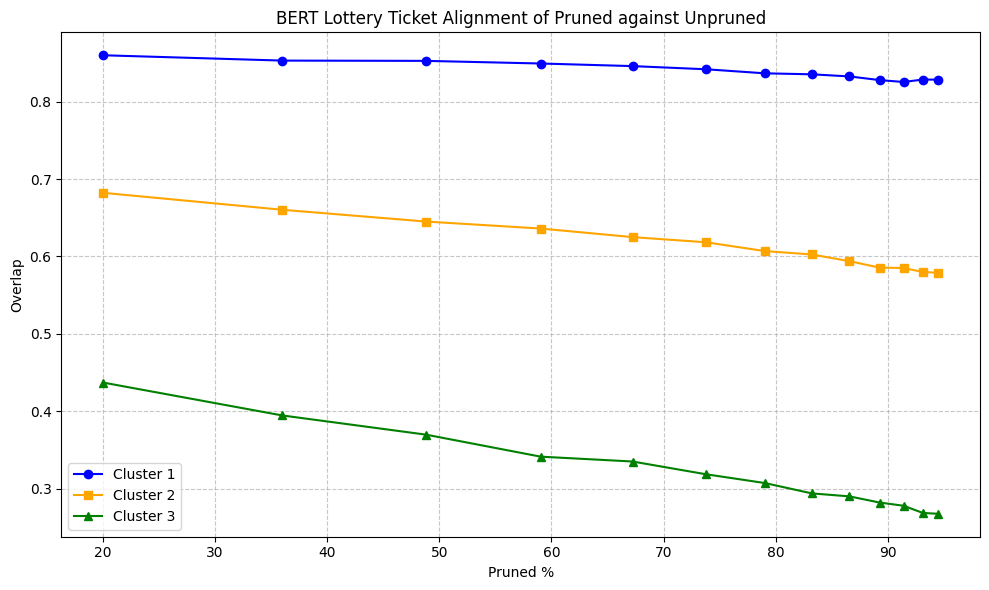

In [64]:
alignment_changes = []
w=0
for root in os.listdir("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/overlap_w_orig"):
    #if w==1: break
    w+=1
    if '.ipy' in root: continue
    root = os.path.join("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/overlap_w_orig", root)
    
    stored_alignments=get_aligments(root, active_neuron_per_cluster)
    alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)
    if alignment_changes:
        for i in range(len(alignment_change)):
            temp={}
            for prunepercent, align in alignment_changes[-1][i].items():
                temp[prunepercent] = align + alignment_change[i][prunepercent]
            alignment_changes[-1][i] = temp
    else:
        change=[]
        for i,cluster in enumerate(alignment_change):
            change.append(cluster)
        alignment_changes.append(change)
 

for i,cluster in enumerate(alignment_changes[0]):
    for percent, comb in cluster.items():
        
        alignment_changes[0][i][percent] = comb/2
avergae_alignment = alignment_changes[0]
plot("BERT Lottery Ticket Alignment of Pruned against Unpruned",avergae_alignment)

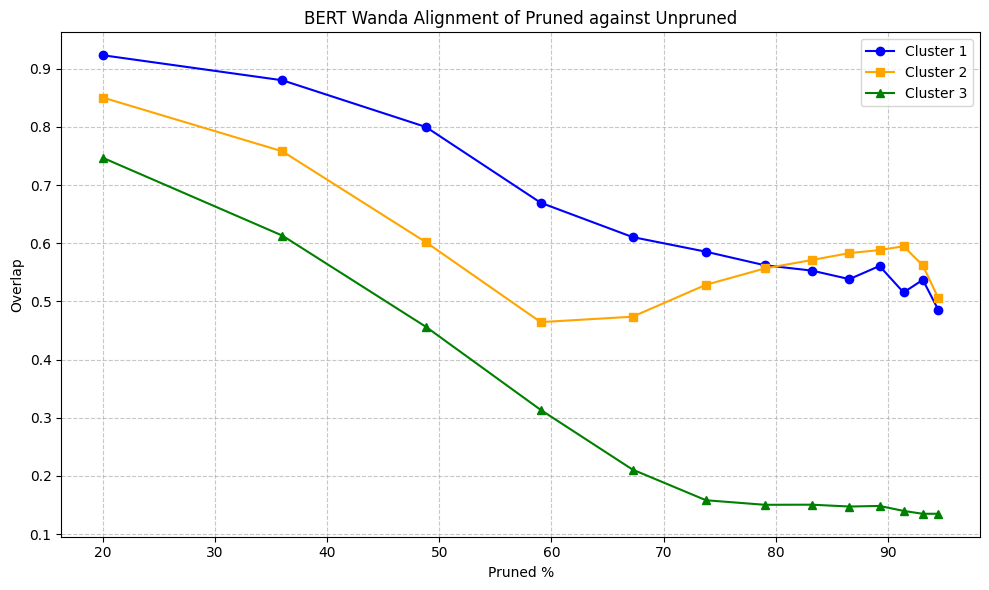

In [65]:
c1=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
c2=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
c3=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']


active_neuron_per_cluster=[c1,c2,c3]

alignment_changes = []
w=0
for root in os.listdir("/workspace/CCE_NLI/BERT/overlap/wanda/overlap_w_orig"):
    #if w==1: break
    w+=1
    if '.ipy' in root: continue
    root = os.path.join("/workspace/CCE_NLI/BERT/overlap/wanda/overlap_w_orig", root)
    
    stored_alignments=get_aligments(root, active_neuron_per_cluster)
    alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)
    if alignment_changes:
        for i in range(len(alignment_change)):
            temp={}
            for prunepercent, align in alignment_changes[-1][i].items():
                temp[prunepercent] = align + alignment_change[i][prunepercent]
            alignment_changes[-1][i] = temp
    else:
        change=[]
        for i,cluster in enumerate(alignment_change):
            change.append(cluster)
        alignment_changes.append(change)
 

for i,cluster in enumerate(alignment_changes[0]):
    for percent, comb in cluster.items():
        
        alignment_changes[0][i][percent] = comb/2
avergae_alignment = alignment_changes[0]
plot("BERT Wanda Alignment of Pruned against Unpruned",avergae_alignment)

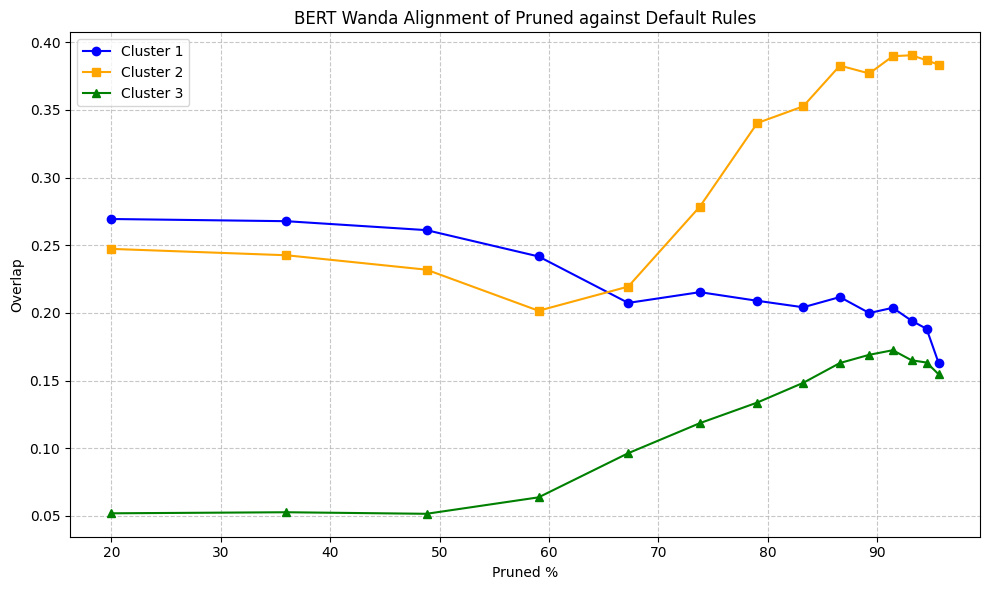

In [66]:
c1=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
c2=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
c3=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']


active_neuron_per_cluster=[c1,c2,c3]

alignment_changes = []
w=0
for root in os.listdir("/workspace/CCE_NLI/BERT/overlap/wanda/overlap_w_pretrained"):
    #if w==1: break
    w+=1
    if '.ipy' in root: continue
    root = os.path.join("/workspace/CCE_NLI/BERT/overlap/wanda/overlap_w_pretrained", root)
    
    stored_alignments=get_aligments(root, active_neuron_per_cluster)
    alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)
    if alignment_changes:
        for i in range(len(alignment_change)):
            temp={}
            for prunepercent, align in alignment_changes[-1][i].items():
                temp[prunepercent] = align + alignment_change[i][prunepercent]
            alignment_changes[-1][i] = temp
    else:
        change=[]
        for i,cluster in enumerate(alignment_change):
            change.append(cluster)
        alignment_changes.append(change)
 

for i,cluster in enumerate(alignment_changes[0]):
    for percent, comb in cluster.items():
        
        alignment_changes[0][i][percent] = comb/2
avergae_alignment = alignment_changes[0]
plot("BERT Wanda Alignment of Pruned against Default Rules",avergae_alignment)

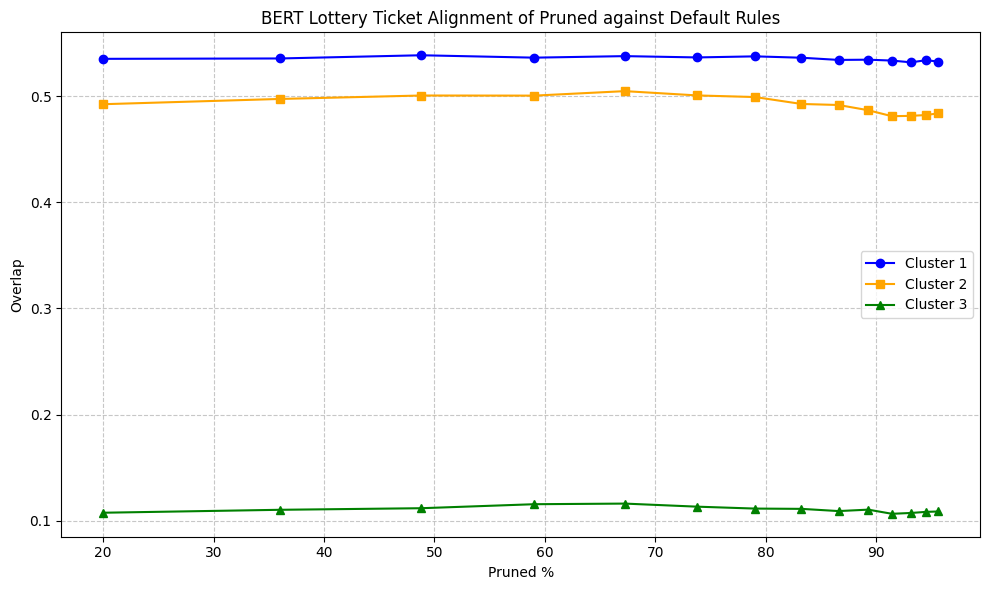

In [67]:
c1=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
c2=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
c3=pd.read_csv("/workspace/CCE_NLI/BERT/exp/wanda/Run3/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']


active_neuron_per_cluster=[c1,c2,c3]

alignment_changes = []
w=0
for root in os.listdir("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/overlap_w_pretrained"):
    #if w==1: break
    w+=1
    if '.ipy' in root: continue
    root = os.path.join("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/overlap_w_pretrained", root)
    
    stored_alignments=get_aligments(root, active_neuron_per_cluster)
    alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)
    if alignment_changes:
        for i in range(len(alignment_change)):
            temp={}
            for prunepercent, align in alignment_changes[-1][i].items():
                temp[prunepercent] = align + alignment_change[i][prunepercent]
            alignment_changes[-1][i] = temp
    else:
        change=[]
        for i,cluster in enumerate(alignment_change):
            change.append(cluster)
        alignment_changes.append(change)
 

for i,cluster in enumerate(alignment_changes[0]):
    for percent, comb in cluster.items():
        
        alignment_changes[0][i][percent] = comb/2
avergae_alignment = alignment_changes[0]
plot("BERT Lottery Ticket Alignment of Pruned against Default Rules",avergae_alignment)

In [68]:
ious=list(stored_alignments[89.2626953125]['Cluster3'].values())
sum(ious)/len(ious)

0.05557738095238089

In [34]:
ious=list(pd.read_csv("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run3/Cluster2/Alignment_between_pruning_iteration_0_and_random.csv")['iou'])

In [39]:
ious = [convert(iou) for iou in ious]

In [42]:
sum(ious)/len(ious)

0.3046840819661156